<a href="https://colab.research.google.com/github/Addreta/-fermi-hubbard-classical-benchmarks/blob/main/pauli_path_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install quspin openfermion qiskit qiskit-aer qiskit-nature qiskit-algorithms physics-tenpy

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.5/38.5 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [ ]:

from openfermion.hamiltonians import fermi_hubbard
from openfermion.transforms import jordan_wigner
from qiskit.quantum_info import SparsePauliOp
import numpy as np

L = 4
t_hop = 1.0
U = 2.0
n_qubits = 2 * L

def openfermion_to_qiskit(qubit_operator, n_qubits):
    pauli_list = []
    for term, coeff in qubit_operator.terms.items():
        if abs(coeff) < 1e-10:
            continue
        pauli_str = ['I'] * n_qubits
        for qubit_idx, pauli in term:
            pauli_str[qubit_idx] = pauli
        pauli_str = ''.join(reversed(pauli_str))
        pauli_list.append((pauli_str, coeff.real))
    return SparsePauliOp.from_list(pauli_list)

fh_op = fermi_hubbard(x_dimension=L, y_dimension=1,
                       tunneling=t_hop, coulomb=U, periodic=False)
jw_op = jordan_wigner(fh_op)
H_qiskit = openfermion_to_qiskit(jw_op, n_qubits)

print(f"H_qiskit built: {len(H_qiskit.to_list())} Pauli terms")
print(f"n_qubits: {n_qubits}")

H_qiskit built: 25 Pauli terms
n_qubits: 8


In [ ]:
def build_trotter_gates(H_qiskit, dt, n_qubits, order=2):
    pauli_list = H_qiskit.to_list()

    hop_gates = []
    int_gates = []

    for pauli_str, coeff in pauli_list:
        if abs(coeff) < 1e-10:
            continue
        if pauli_str == 'I' * n_qubits:
            continue
        pauli_tuple = tuple(reversed(pauli_str))
        if 'X' in pauli_str or 'Y' in pauli_str:
            hop_gates.append((pauli_tuple, coeff.real * dt))
        else:
            int_gates.append((pauli_tuple, coeff.real * dt))

    if order == 2:
        gates = ([(p, a/2) for p, a in hop_gates] +
                 int_gates +
                 [(p, a/2) for p, a in hop_gates])
    else:
        gates = hop_gates + int_gates

    return gates

dt_pp = 0.1
gates_one_step = build_trotter_gates(H_qiskit, dt_pp, n_qubits, order=2)
print(f"Number of gates per Trotter step: {len(gates_one_step)}")
print(f"First few gates:")
for g, a in gates_one_step[:3]:
    print(f"  {g}: angle={a:.4f}")

Number of gates per Trotter step: 36
First few gates:
  ('Y', 'Z', 'Y', 'I', 'I', 'I', 'I', 'I'): angle=-0.0250
  ('X', 'Z', 'X', 'I', 'I', 'I', 'I', 'I'): angle=-0.0250
  ('I', 'Y', 'Z', 'Y', 'I', 'I', 'I', 'I'): angle=-0.0250


In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Pauli matrices
I = np.eye(2, dtype=complex)
X = np.array([[0,1],[1,0]], dtype=complex)
Y = np.array([[0,-1j],[1j,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)
PAULIS = {'I': I, 'X': X, 'Y': Y, 'Z': Z}

def pauli_path_simulate(observable_init, gates_one_step, n_steps,
                         psi0, n_qubits, epsilon=1e-3):
    all_gates = gates_one_step * n_steps
    all_gates_reversed = list(reversed(all_gates))
    observable = dict(observable_init)
    for gate_pauli, angle in all_gates_reversed:
        observable = apply_gate_backward(observable, gate_pauli,
                                          angle, n_qubits, epsilon)
    result = 0.0
    for pauli_str, coeff in observable.items():
        mat = np.array([[1.0+0j]])
        for p in pauli_str:
            mat = np.kron(mat, PAULIS[p])
        result += coeff * (psi0.conj() @ mat @ psi0)
    return np.real(result)

def build_neel_observable(L, n_qubits):
    obs = {}
    for i in range(L):
        up_qubit   = 2 * i
        down_qubit = 2 * i + 1
        sign = (-1)**i
        pauli = ['I'] * n_qubits
        pauli[up_qubit] = 'Z'
        obs[tuple(pauli)] = obs.get(tuple(pauli), 0) + sign * (-0.25) / L
        pauli = ['I'] * n_qubits
        pauli[down_qubit] = 'Z'
        obs[tuple(pauli)] = obs.get(tuple(pauli), 0) + sign * (0.25) / L
    return obs

# Initial state
qc_init = QuantumCircuit(n_qubits)
for q in [0, 4, 3, 7]:
    qc_init.x(q)
psi0_pp = Statevector(qc_init).data

# Verify
obs_init = build_neel_observable(L, n_qubits)
neel_check = pauli_path_simulate(obs_init, [], 0, psi0_pp, n_qubits, epsilon=0)
print(f"Initial Neel value (should be 0.5): {neel_check:.4f}")
print(f"Number of terms in observable: {len(obs_init)}")

Initial Neel value (should be 0.5): 0.5000
Number of terms in observable: 8


In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp
from openfermion.hamiltonians import fermi_hubbard
from openfermion.transforms import jordan_wigner

# ── Pauli matrices ──
I_m = np.eye(2, dtype=complex)
X_m = np.array([[0,1],[1,0]], dtype=complex)
Y_m = np.array([[0,-1j],[1j,0]], dtype=complex)
Z_m = np.array([[1,0],[0,-1]], dtype=complex)
PAULIS = {'I': I_m, 'X': X_m, 'Y': Y_m, 'Z': Z_m}

# ── Parameters ──
L = 4
t_hop = 1.0
U = 2.0
n_qubits = 2 * L

# ── Build Hamiltonian ──
def openfermion_to_qiskit(qubit_operator, n_qubits):
    pauli_list = []
    for term, coeff in qubit_operator.terms.items():
        if abs(coeff) < 1e-10:
            continue
        pauli_str = ['I'] * n_qubits
        for qubit_idx, pauli in term:
            pauli_str[qubit_idx] = pauli
        pauli_str = ''.join(reversed(pauli_str))
        pauli_list.append((pauli_str, coeff.real))
    return SparsePauliOp.from_list(pauli_list)

fh_op = fermi_hubbard(x_dimension=L, y_dimension=1,
                       tunneling=t_hop, coulomb=U, periodic=False)
H_qiskit = openfermion_to_qiskit(jordan_wigner(fh_op), n_qubits)

# ── Pauli commutator ──
def pauli_commutes(P, Q, n_qubits):
    anticommute_count = 0
    for i in range(n_qubits):
        p, q = P[i], Q[i]
        if p == 'I' or q == 'I':
            continue
        if p != q:
            anticommute_count += 1
    return (anticommute_count % 2) == 0

def pauli_commutator_coeff(P, Q, n_qubits):
    if pauli_commutes(P, Q, n_qubits):
        return 0, None
    coeff = 1.0 + 0j
    result = []
    pairs = {('X','Y'): (1j,'Z'), ('Y','X'): (-1j,'Z'),
             ('Y','Z'): (1j,'X'), ('Z','Y'): (-1j,'X'),
             ('Z','X'): (1j,'Y'), ('X','Z'): (-1j,'Y')}
    for i in range(n_qubits):
        p, q = P[i], Q[i]
        if p == 'I':
            result.append(q)
        elif q == 'I':
            result.append(p)
        elif p == q:
            result.append('I')
        else:
            c, r = pairs[(p, q)]
            coeff *= c
            result.append(r)
    return 2 * coeff, tuple(result)

# ── Apply gate backward ──
def apply_gate_backward(observable, gate_pauli, angle, n_qubits, epsilon):
    new_observable = {}
    for pauli_str, coeff in observable.items():
        if pauli_commutes(gate_pauli, pauli_str, n_qubits):
            new_observable[pauli_str] = new_observable.get(pauli_str, 0) + coeff
        else:
            c_comm, R = pauli_commutator_coeff(gate_pauli, pauli_str, n_qubits)
            cos_term = np.cos(2 * angle) * coeff
            sin_term = 1j * np.sin(2 * angle) * (c_comm / 2) * coeff
            new_observable[pauli_str] = new_observable.get(pauli_str, 0) + cos_term
            if R is not None:
                new_observable[R] = new_observable.get(R, 0) + sin_term
    return {k: v for k, v in new_observable.items() if abs(v) > epsilon}

# ── Build Trotter gates ──
def build_trotter_gates(H_qiskit, dt, n_qubits, order=2):
    pauli_list = H_qiskit.to_list()
    hop_gates = []
    int_gates = []
    for pauli_str, coeff in pauli_list:
        if abs(coeff) < 1e-10:
            continue
        if pauli_str == 'I' * n_qubits:
            continue
        pauli_tuple = tuple(reversed(pauli_str))
        if 'X' in pauli_str or 'Y' in pauli_str:
            hop_gates.append((pauli_tuple, coeff.real * dt))
        else:
            int_gates.append((pauli_tuple, coeff.real * dt))
    if order == 2:
        gates = ([(p, a/2) for p, a in hop_gates] +
                 int_gates +
                 [(p, a/2) for p, a in hop_gates])
    else:
        gates = hop_gates + int_gates
    return gates

# ── Pauli path simulation ──
def pauli_path_simulate(observable_init, gates_one_step, n_steps,
                         psi0, n_qubits, epsilon=1e-3):
    all_gates = gates_one_step * n_steps
    all_gates_reversed = list(reversed(all_gates))
    observable = dict(observable_init)
    for gate_pauli, angle in all_gates_reversed:
        observable = apply_gate_backward(observable, gate_pauli,
                                          angle, n_qubits, epsilon)
    result = 0.0
    for pauli_str, coeff in observable.items():
        mat = np.array([[1.0+0j]])
        for p in pauli_str:
            mat = np.kron(mat, PAULIS[p])
        result += coeff * (psi0.conj() @ mat @ psi0)
    return np.real(result)

# ── Build Neel observable ──
def build_neel_observable(L, n_qubits):
    obs = {}
    for i in range(L):
        up_qubit   = 2 * i
        down_qubit = 2 * i + 1
        sign = (-1)**i
        pauli = ['I'] * n_qubits
        pauli[up_qubit] = 'Z'
        obs[tuple(pauli)] = obs.get(tuple(pauli), 0) + sign * (-0.25) / L
        pauli = ['I'] * n_qubits
        pauli[down_qubit] = 'Z'
        obs[tuple(pauli)] = obs.get(tuple(pauli), 0) + sign * (0.25) / L
    return obs

# ── Initial state ──
qc_init = QuantumCircuit(n_qubits)
for q in [0, 4, 3, 7]:
    qc_init.x(q)
psi0_pp = Statevector(qc_init).data

# ── Gates ──
dt_pp = 0.1
gates_one_step = build_trotter_gates(H_qiskit, dt_pp, n_qubits, order=2)

print(f"Setup complete.")
print(f"Gates per step: {len(gates_one_step)}")
print(f"Initial Neel: {pauli_path_simulate(build_neel_observable(L, n_qubits), [], 0, psi0_pp, n_qubits, 0):.4f}")

Setup complete.
Gates per step: 36
Initial Neel: 0.5000


Hermiticity check passed!
Symmetry checks passed!
Particle conservation check passed!
Exact done.
ε=1e-01 done. Final m(t)=0.0000
ε=1e-02 done. Final m(t)=0.3223
ε=1e-03 done. Final m(t)=0.0185
All Pauli path done.


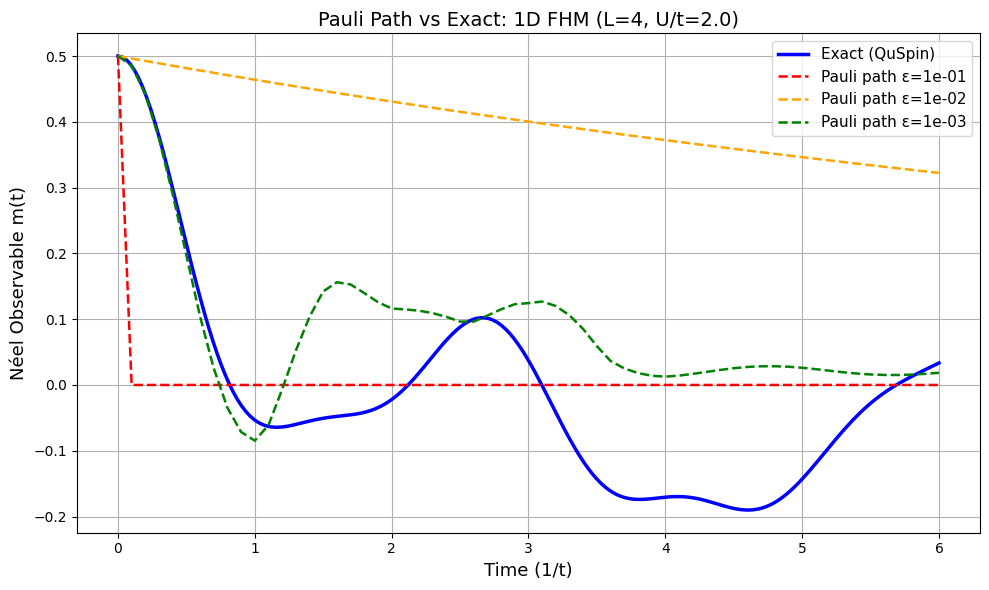

In [ ]:
from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d
import matplotlib.pyplot as plt
# ── Exact solution (QuSpin) ──
basis = spinful_fermion_basis_1d(L, Nf=(2, 2))
hop = [[-t_hop, i, i+1] for i in range(L-1)] + [[-t_hop, i+1, i] for i in range(L-1)]
interaction = [[U, i, i] for i in range(L)]
static = [["+-|", hop], ["|+-", hop], ["n|n", interaction]]
H_qs = hamiltonian(static, [], basis=basis, dtype=np.complex128)

neel_state = basis.index("1010", "0101")
psi0_qs = np.zeros(basis.Ns, dtype=np.complex128)
psi0_qs[neel_state] = 1.0

def build_Sz(site, basis):
    static_sz = [["n|", [[0.5, site]]], ["|n", [[-0.5, site]]]]
    return hamiltonian(static_sz, [], basis=basis, dtype=np.complex128,
                       check_symm=False, check_herm=False, check_pcon=False)

Sz_ops = [build_Sz(i, basis) for i in range(L)]
times_exact = np.linspace(0, 6.0, 200)
psi_t = H_qs.evolve(psi0_qs, 0, times_exact)
neel_exact = np.zeros(len(times_exact))
for i in range(L):
    Sz_expect = np.real(np.einsum('it,ij,jt->t',
                        psi_t.conj(), Sz_ops[i].toarray(), psi_t))
    neel_exact += ((-1)**i) * Sz_expect
neel_exact /= L
print("Exact done.")

# ── Pauli path time evolution ──
t_max = 6.0
n_steps_total = int(t_max / dt_pp)
times_pp = np.linspace(0, t_max, n_steps_total + 1)

epsilon_values = [1e-1, 1e-2, 1e-3]
colors_pp = ['red', 'orange', 'green']
neel_pp_results = {}

for epsilon in epsilon_values:
    neel_pp = [0.5]
    for step in range(1, n_steps_total + 1):
        obs = build_neel_observable(L, n_qubits)
        m = pauli_path_simulate(obs, gates_one_step,
                                 step, psi0_pp, n_qubits, epsilon)
        neel_pp.append(m)
    neel_pp_results[epsilon] = neel_pp
    print(f"ε={epsilon:.0e} done. Final m(t)={neel_pp[-1]:.4f}")

print("All Pauli path done.")

# ── Plot ──
plt.figure(figsize=(10, 6))
plt.plot(times_exact, neel_exact, 'b-', linewidth=2.5, label='Exact (QuSpin)')
for epsilon, color in zip(epsilon_values, colors_pp):
    plt.plot(times_pp, neel_pp_results[epsilon], color=color,
             linestyle='--', linewidth=1.8, label=f'Pauli path ε={epsilon:.0e}')

plt.xlabel('Time (1/t)', fontsize=13)
plt.ylabel('Néel Observable m(t)', fontsize=13)
plt.title(f'Pauli Path vs Exact: 1D FHM (L={L}, U/t={U})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.savefig('pauli_path_neel.png', dpi=150)
plt.show()

ε=1e-03 done. Final m(t)=0.0185
ε=1e-04 done. Final m(t)=-0.0073
ε=1e-05 done. Final m(t)=0.0326


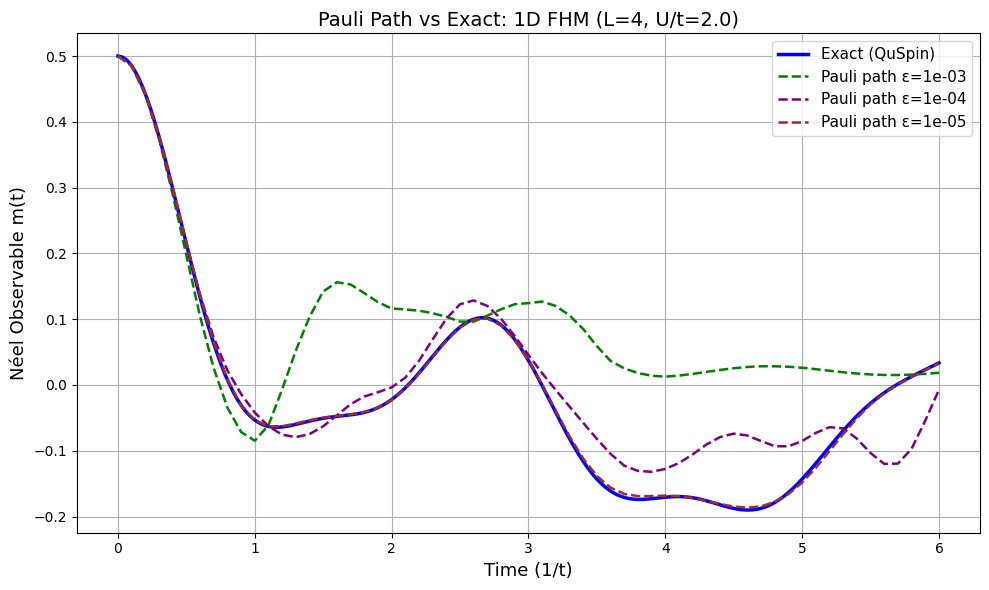

In [ ]:
epsilon_values_fine = [1e-3, 1e-4, 1e-5]
colors_fine = ['green', 'purple', 'brown']
neel_pp_fine = {}

for epsilon in epsilon_values_fine:
    neel_pp = [0.5]
    for step in range(1, n_steps_total + 1):
        obs = build_neel_observable(L, n_qubits)
        m = pauli_path_simulate(obs, gates_one_step,
                                 step, psi0_pp, n_qubits, epsilon)
        neel_pp.append(m)
    neel_pp_fine[epsilon] = neel_pp
    print(f"ε={epsilon:.0e} done. Final m(t)={neel_pp[-1]:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(times_exact, neel_exact, 'b-', linewidth=2.5, label='Exact (QuSpin)')
for epsilon, color in zip(epsilon_values_fine, colors_fine):
    plt.plot(times_pp, neel_pp_fine[epsilon], color=color,
             linestyle='--', linewidth=1.8, label=f'Pauli path ε={epsilon:.0e}')

plt.xlabel('Time (1/t)', fontsize=13)
plt.ylabel('Néel Observable m(t)', fontsize=13)
plt.title(f'Pauli Path vs Exact: 1D FHM (L={L}, U/t={U})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.savefig('pauli_path_fine.png', dpi=150)
plt.show()

ε=1e-01: m=0.0000, error=0.037179
ε=1e-02: m=0.4003, error=0.363166
ε=1e-03: m=0.1244, error=0.087242
ε=1e-04: m=0.0456, error=0.008440
ε=1e-05: m=0.0377, error=0.000500


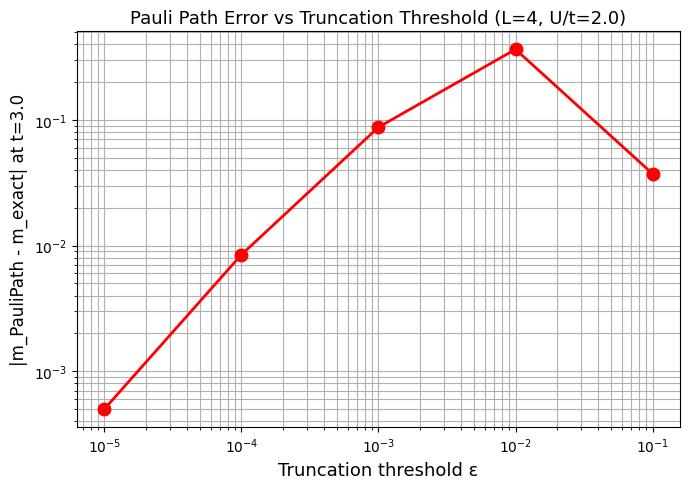

In [ ]:
# Error vs epsilon at fixed time (analogous to Trotter error vs dt, TDVP error vs chi)
t_fixed = 3.0
step_fixed = int(t_fixed / dt_pp)
neel_exact_t = np.interp(t_fixed, times_exact, neel_exact)

epsilon_test = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
errors_pp = []

for epsilon in epsilon_test:
    obs = build_neel_observable(L, n_qubits)
    m = pauli_path_simulate(obs, gates_one_step,
                             step_fixed, psi0_pp, n_qubits, epsilon)
    err = abs(m - neel_exact_t)
    errors_pp.append(err)
    print(f"ε={epsilon:.0e}: m={m:.4f}, error={err:.6f}")

plt.figure(figsize=(7, 5))
plt.loglog(epsilon_test, errors_pp, 'ro-', linewidth=2, markersize=9)
plt.xlabel('Truncation threshold ε', fontsize=13)
plt.ylabel(f'|m_PauliPath - m_exact| at t={t_fixed}', fontsize=12)
plt.title(f'Pauli Path Error vs Truncation Threshold (L={L}, U/t={U})', fontsize=13)
plt.grid(True, which='both')
plt.tight_layout()
plt.savefig('pauli_path_error_vs_epsilon.png', dpi=150)
plt.show()

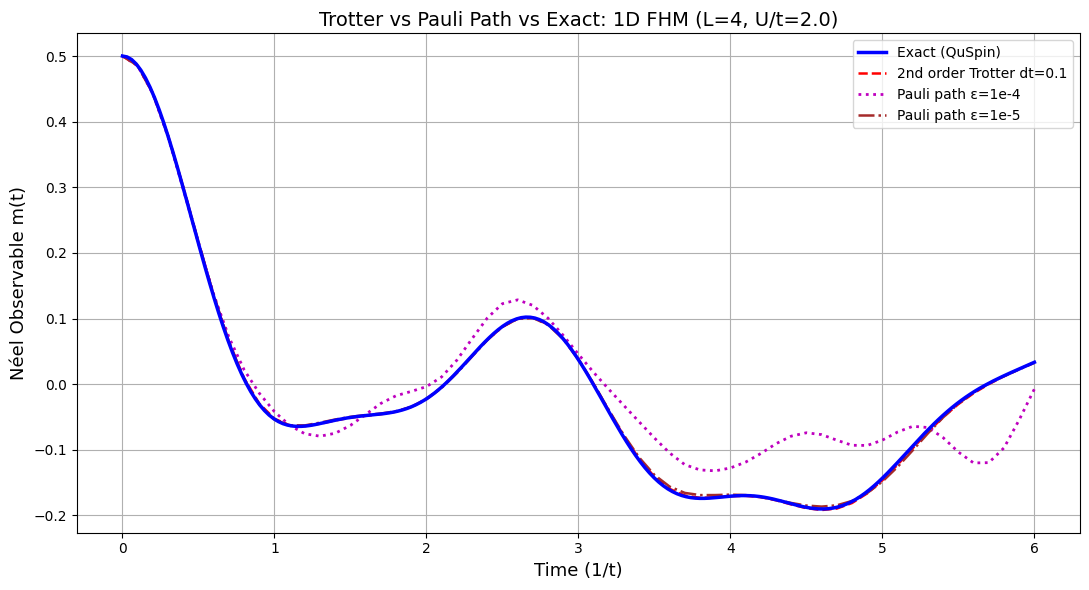

In [ ]:
# Final comparison plot
from scipy.linalg import expm
from qiskit.quantum_info import SparsePauliOp

# Recompute Trotter 2nd order dt=0.1
pauli_list_q = H_qiskit.to_list()
H_hop_matrix = SparsePauliOp.from_list([(p,c) for p,c in pauli_list_q
                                         if 'X' in p or 'Y' in p]).to_matrix()
H_int_matrix = SparsePauliOp.from_list([(p,c) for p,c in pauli_list_q
                                         if 'X' not in p and 'Y' not in p]).to_matrix()
H_matrix = H_qiskit.to_matrix()

def build_Sz_matrix(site, n_qubits):
    up_qubit   = 2 * site
    down_qubit = 2 * site + 1
    up_str   = 'I'*(n_qubits-up_qubit-1) + 'Z' + 'I'*up_qubit
    down_str = 'I'*(n_qubits-down_qubit-1) + 'Z' + 'I'*down_qubit
    return SparsePauliOp.from_list([(up_str,-0.25),(down_str,0.25)]).to_matrix()

Sz_matrices = [build_Sz_matrix(i, n_qubits) for i in range(L)]
def measure_neel_q(psi):
    return sum(((-1)**i)*np.real(psi.conj() @ Sz_matrices[i] @ psi)
               for i in range(L)) / L

dt_tr = 0.1
U_hop_h = expm(-1j*(dt_tr/2)*H_hop_matrix)
U_int_f = expm(-1j*dt_tr*H_int_matrix)
psi = psi0_pp.copy()
neel_2nd = [measure_neel_q(psi)]
times_tr = [0.0]
for step in range(int(6.0/dt_tr)):
    psi = U_hop_h @ (U_int_f @ (U_hop_h @ psi))
    neel_2nd.append(measure_neel_q(psi))
    times_tr.append((step+1)*dt_tr)

# Plot all together
plt.figure(figsize=(11, 6))
plt.plot(times_exact, neel_exact, 'b-', linewidth=2.5, label='Exact (QuSpin)', zorder=5)
plt.plot(times_tr, neel_2nd, 'r--', linewidth=1.8, label='2nd order Trotter dt=0.1')
plt.plot(times_pp, neel_pp_fine[1e-4], 'm:', linewidth=2, label='Pauli path ε=1e-4')
plt.plot(times_pp, neel_pp_fine[1e-5], color='brown', linestyle='-.',
         linewidth=1.8, label='Pauli path ε=1e-5')

plt.xlabel('Time (1/t)', fontsize=13)
plt.ylabel('Néel Observable m(t)', fontsize=13)
plt.title(f'Trotter vs Pauli Path vs Exact: 1D FHM (L={L}, U/t={U})', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.savefig('trotter_paulipath_exact.png', dpi=150)
plt.show()